# Analisis Kepuasan Penumpang Maskapai
## Pendekatan Business Intelligence

Tujuan:
- Mengidentifikasi faktor utama yang memengaruhi kepuasan
- Mengevaluasi layanan & delay
- Memberikan rekomendasi berbasis data

## Import Library & Setup Visual

Pada tahap ini, dilakukan import library yang digunakan untuk analisis data dan visualisasi.

- **pandas & numpy** → untuk pengolahan data  
- **matplotlib & seaborn** → untuk visualisasi  
- **ipywidgets** → untuk membuat dashboard interaktif  

Selain itu, dilakukan pengaturan tampilan grafik agar lebih rapi, jelas, dan mudah dibaca dengan warna yang lebih kontras.

In [1]:
!pip install ipywidgets -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, HTML

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (10,6),
    "axes.titlesize": 14,
    "axes.titleweight": "bold"
})

PALETTE = "Spectral"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.9 MB/s eta 0:00:00


## Load Dataset

Dataset diambil dari Google Drive untuk memudahkan akses dan penyimpanan.

Selanjutnya, data dibaca menggunakan pandas dan ditampilkan beberapa baris pertama untuk memastikan dataset berhasil dimuat dengan benar.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Business Intelligence/UTS/Dataset_AirlinePassengerSatisfaction/train.csv')

df.head()

Mounted at /content/drive


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [4]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


## Data Preprocessing

Pada tahap ini dilakukan pembersihan dan persiapan data sebelum analisis:

- Mengisi missing value pada *Arrival Delay* menggunakan rata-rata
- Menghapus kolom yang tidak diperlukan
- Mengubah label kepuasan menjadi numerik (0 dan 1)
- Mengecek apakah terdapat data duplikat

Langkah ini penting untuk memastikan data bersih dan siap dianalisis.

In [6]:
# Missing value
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].mean()
)

# Drop kolom tidak perlu
df.drop(['Unnamed: 0','id'], axis=1, inplace=True, errors='ignore')

# Encode target
df['satisfaction'] = df['satisfaction'].map({
    'satisfied': 1,
    'neutral or dissatisfied': 0
})

# Cek duplikat
print("Duplicate:", df.duplicated().sum())

Duplicate: 0


## Tingkat Kepuasan

Menghitung rata-rata nilai kepuasan untuk mengetahui proporsi pelanggan yang puas terhadap layanan maskapai.

In [7]:
rate = df['satisfaction'].mean()*100
print(f"Tingkat Kepuasan: {rate:.2f}%")

Tingkat Kepuasan: 43.33%


## Analisis Faktor Kepuasan

Menggunakan korelasi untuk melihat hubungan antara setiap variabel dengan tingkat kepuasan.

Faktor dengan nilai tertinggi menunjukkan pengaruh terbesar terhadap kepuasan pelanggan.

/tmp/ipykernel_3907/4074506090.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette=PALETTE)


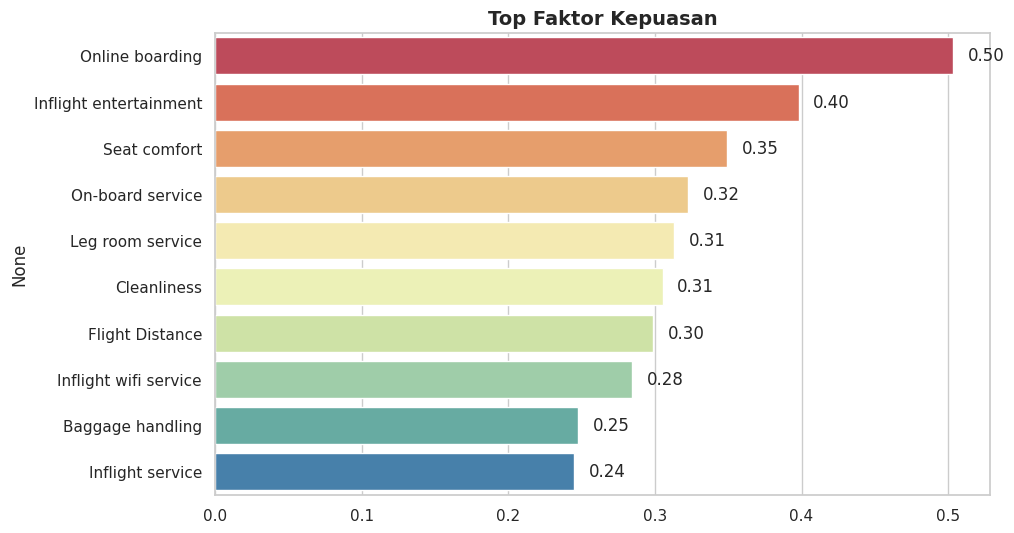

In [8]:
corr = df.select_dtypes(include='number').corr()['satisfaction'].sort_values(ascending=False)
top_corr = corr.drop('satisfaction').head(10)

sns.barplot(x=top_corr.values, y=top_corr.index, palette=PALETTE)
plt.title('Top Faktor Kepuasan')

for i, v in enumerate(top_corr.values):
    plt.text(v+0.01, i, f"{v:.2f}", va='center')

plt.show()

## Bar Chart - Kualitas Layanan

Menampilkan rata-rata penilaian setiap layanan untuk melihat layanan dengan performa tertinggi dan terendah.

/tmp/ipykernel_3907/1854003716.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_scores.values, y=avg_scores.index, palette=PALETTE)


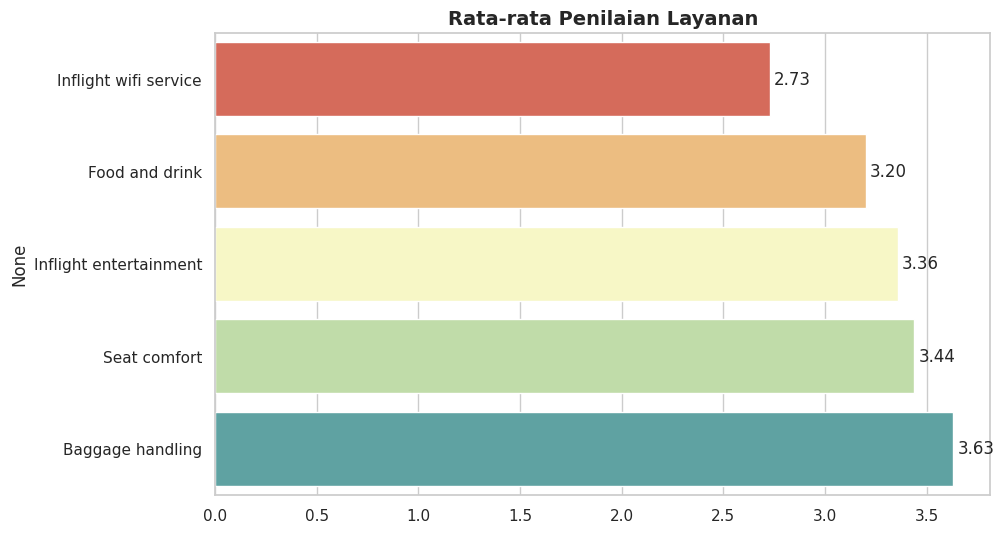

In [20]:
services = [
    'Inflight wifi service','Seat comfort','Food and drink',
    'Baggage handling','Inflight entertainment'
]

avg_scores = df[services].mean().sort_values()

sns.barplot(x=avg_scores.values, y=avg_scores.index, palette=PALETTE)
plt.title('Rata-rata Penilaian Layanan')

for i, v in enumerate(avg_scores.values):
    plt.text(v + 0.02, i, f"{v:.2f}", va='center')

plt.show()

## Pie Chart - Distribusi Kelas

Menampilkan proporsi pelanggan berdasarkan kelas penerbangan untuk memahami komposisi pelanggan.

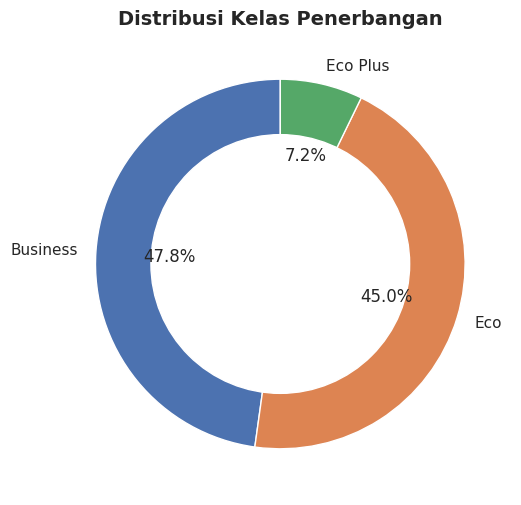

In [21]:
class_counts = df['Class'].value_counts()

plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribusi Kelas Penerbangan')
plt.show()

## Heatmap - Korelasi

Menampilkan hubungan antar variabel numerik untuk melihat pola keterkaitan dalam data.

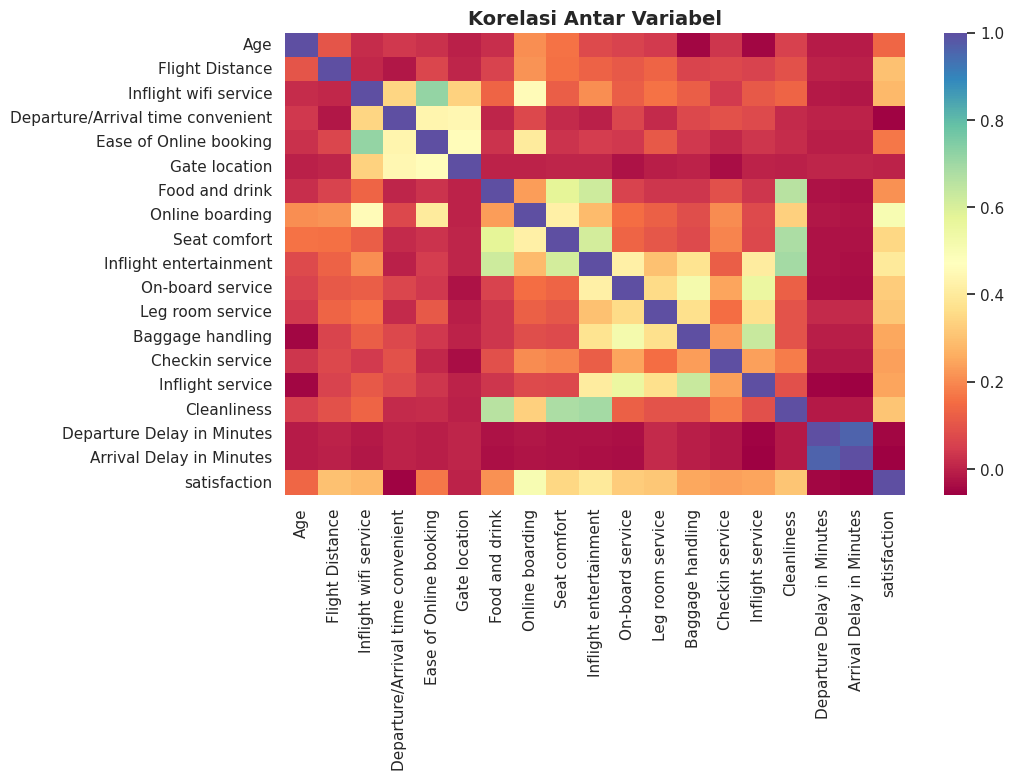

In [22]:
corr_all = df.select_dtypes(include='number').corr()

sns.heatmap(corr_all, cmap=PALETTE)
plt.title('Korelasi Antar Variabel')
plt.show()

## Perbandingan Kualitas Layanan

Analisis ini menunjukkan perbedaan kualitas layanan antara pelanggan puas dan tidak puas.

Layanan dengan perbedaan signifikan dapat menjadi fokus utama untuk peningkatan.

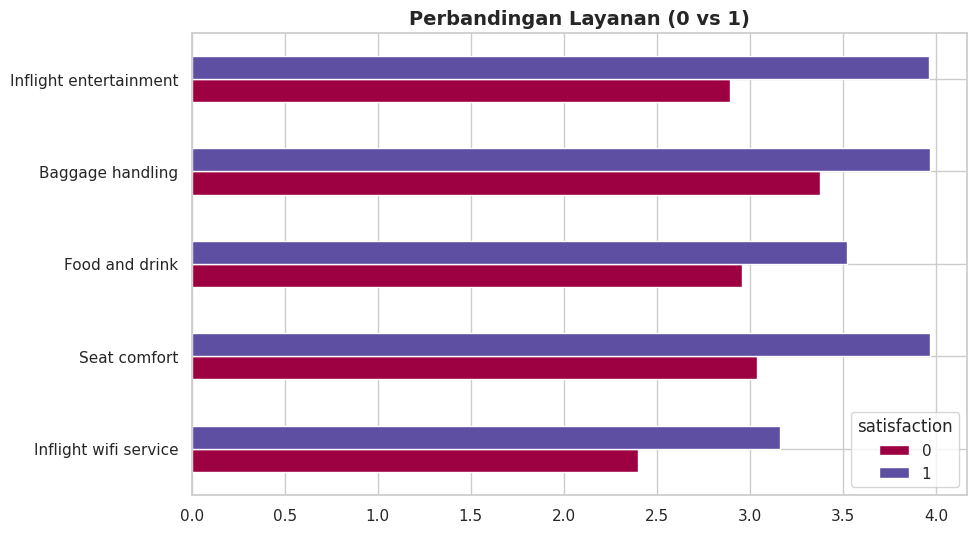

In [9]:
services = [
    'Inflight wifi service','Seat comfort','Food and drink',
    'Baggage handling','Inflight entertainment'
]

service_sat = df.groupby('satisfaction')[services].mean().T

service_sat.plot(kind='barh', colormap=PALETTE)
plt.title('Perbandingan Layanan (0 vs 1)')
plt.show()

## Pengaruh Delay terhadap Kepuasan

Analisis ini membandingkan delay antara pelanggan puas dan tidak puas.

Jika delay lebih tinggi pada pelanggan tidak puas, maka keterlambatan menjadi faktor penting yang perlu diperbaiki.

/tmp/ipykernel_3907/607568266.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='satisfaction', y='Departure Delay in Minutes', palette=PALETTE)


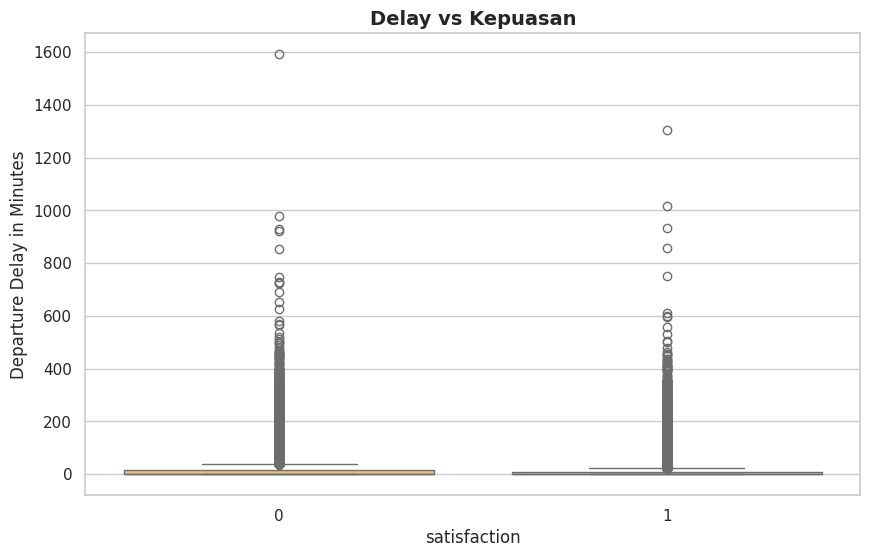

,Departure Delay in Minutes
satisfaction,
0,16.503728
1,12.608084


In [10]:
sns.boxplot(data=df, x='satisfaction', y='Departure Delay in Minutes', palette=PALETTE)
plt.title('Delay vs Kepuasan')
plt.show()

df.groupby('satisfaction')['Departure Delay in Minutes'].mean()

## Segmentasi Kepuasan Pelanggan

Analisis ini menunjukkan bagaimana tingkat kepuasan berbeda antar segmen pelanggan.

Hasilnya dapat digunakan untuk menentukan strategi layanan yang lebih tepat untuk setiap segmen.

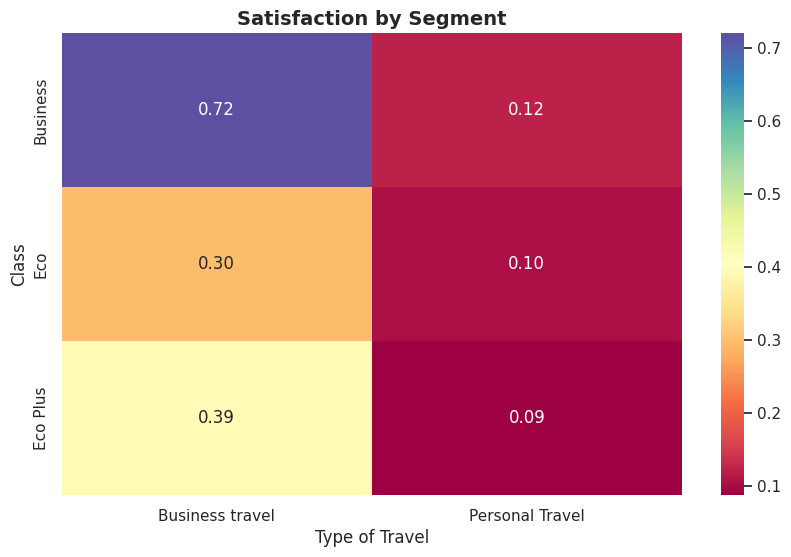

In [11]:
pivot = pd.pivot_table(
    df,
    values='satisfaction',
    index='Class',
    columns='Type of Travel',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, cmap=PALETTE, fmt=".2f")
plt.title('Satisfaction by Segment')
plt.show()

## Distribusi Usia

Menampilkan sebaran usia pelanggan untuk memahami karakteristik demografi.

Distribusi ini membantu melihat kelompok usia yang paling dominan dalam dataset.

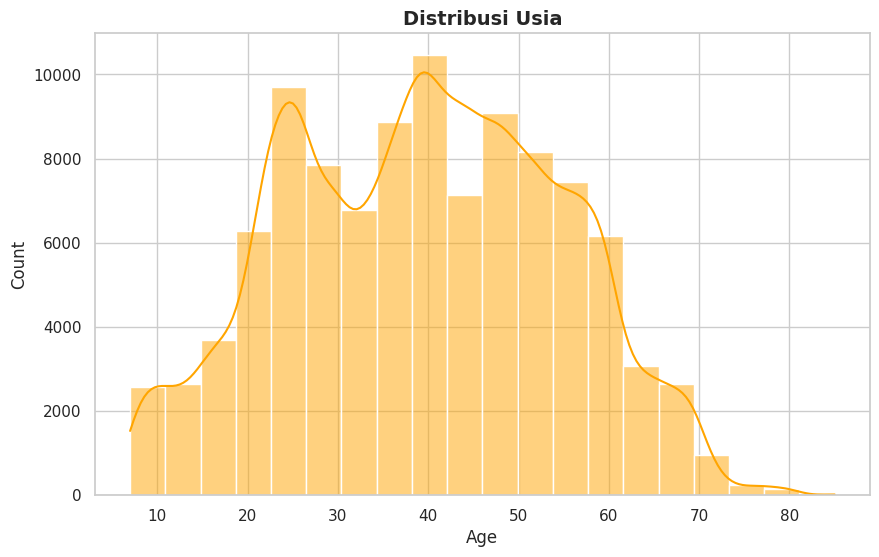

In [12]:
sns.histplot(df['Age'], bins=20, kde=True, color='orange')
plt.title('Distribusi Usia')
plt.show()

## Evaluasi Hasil

Menampilkan ringkasan metrik utama sebagai hasil akhir analisis.

Metrik ini memberikan gambaran cepat mengenai tingkat kepuasan pelanggan serta perbedaan delay antara pelanggan puas dan tidak puas.

In [13]:
eval_table = pd.DataFrame({
    "Metric": [
        "Satisfaction Rate",
        "Avg Delay (Satisfied)",
        "Avg Delay (Not Satisfied)"
    ],
    "Value": [
        f"{df['satisfaction'].mean()*100:.2f}%",
        f"{df[df['satisfaction']==1]['Departure Delay in Minutes'].mean():.2f}",
        f"{df[df['satisfaction']==0]['Departure Delay in Minutes'].mean():.2f}"
    ]
})

eval_table

,Metric,Value
0,Satisfaction Rate,43.33%
1,Avg Delay (Satisfied),12.61
2,Avg Delay (Not Satisfied),16.50


## Visualisasi Evaluasi

Menampilkan perbandingan metrik utama dalam bentuk grafik agar lebih mudah dibaca dan dibandingkan.

Visualisasi ini membantu melihat perbedaan tingkat kepuasan dan delay secara lebih intuitif.

/tmp/ipykernel_3907/44554092.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=labels, palette=PALETTE)


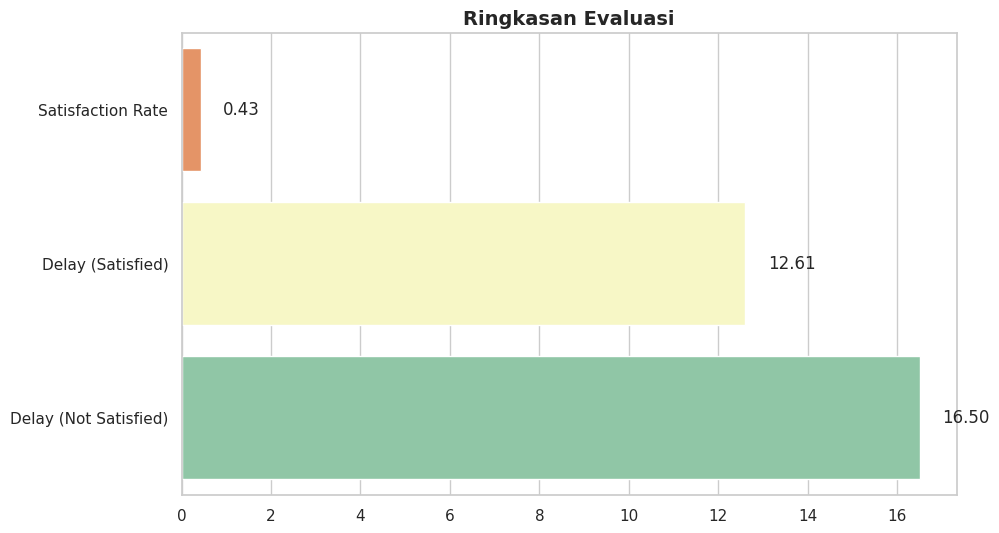

In [14]:
values = [
    df['satisfaction'].mean(),
    df[df['satisfaction']==1]['Departure Delay in Minutes'].mean(),
    df[df['satisfaction']==0]['Departure Delay in Minutes'].mean()
]

labels = ['Satisfaction Rate','Delay (Satisfied)','Delay (Not Satisfied)']

sns.barplot(x=values, y=labels, palette=PALETTE)
plt.title('Ringkasan Evaluasi')

for i, v in enumerate(values):
    plt.text(v+0.5, i, f"{v:.2f}", va='center')

plt.show()

## Filter Dashboard

Menyediakan filter interaktif berdasarkan kelas dan gender untuk memudahkan eksplorasi data.

Filter ini memungkinkan pengguna melihat perubahan hasil analisis sesuai dengan segmen yang dipilih.

In [16]:
class_filter = widgets.Dropdown(
    options=['All'] + list(df['Class'].unique()),
    value='All',
    description='Class:'
)

gender_filter = widgets.Dropdown(
    options=['All'] + list(df['Gender'].unique()),
    value='All',
    description='Gender:'
)

## Key Metrics (KPI)

Menampilkan indikator utama seperti tingkat kepuasan dan rata-rata delay dalam bentuk visual sederhana.

Tujuannya untuk memudahkan pemahaman secara cepat tanpa perlu melihat detail data.

In [17]:
def show_kpi(title, value):
    display(HTML(f"""
        <div style='background:#f5f5f5;padding:10px;border-radius:10px;
        width:200px;text-align:center;margin:5px;display:inline-block'>
            <h4>{title}</h4>
            <h2>{value}</h2>
        </div>
    """))

## Dashboard Interaktif

Fungsi ini digunakan untuk menampilkan dashboard berdasarkan filter yang dipilih.

Data akan diperbarui secara otomatis sesuai dengan kategori yang dipilih, serta menampilkan:
- KPI utama (tingkat kepuasan dan rata-rata delay)
- Visualisasi kepuasan berdasarkan kelas
- Distribusi delay
- Distribusi usia

Dashboard ini membantu eksplorasi data secara lebih fleksibel dan interaktif.

In [18]:
def update_dashboard(class_val, gender_val):

    data = df.copy()

    if class_val != 'All':
        data = data[data['Class'] == class_val]

    if gender_val != 'All':
        data = data[data['Gender'] == gender_val]

    sat_rate = data['satisfaction'].mean()*100
    delay = data['Departure Delay in Minutes'].mean()

    show_kpi("Satisfaction Rate", f"{sat_rate:.2f}%")
    show_kpi("Avg Delay", f"{delay:.2f}")

    # Visual 1
    sns.barplot(data=data, x='Class', y='satisfaction', palette=PALETTE)
    plt.title('Satisfaction by Class')
    plt.show()

    # Visual 2
    sns.kdeplot(data=data, x='Departure Delay in Minutes', hue='satisfaction', fill=True)
    plt.title('Delay Distribution')
    plt.show()

    # Visual 3
    sns.histplot(data['Age'], bins=20, kde=True, color='orange')
    plt.title('Age Distribution')
    plt.show()

## Menjalankan Dashboard

Menghubungkan filter dengan fungsi dashboard sehingga visualisasi akan berubah secara otomatis sesuai dengan pilihan pengguna.

In [19]:
widgets.interactive(
    update_dashboard,
    class_val=class_filter,
    gender_val=gender_filter
)

interactive(children=(Dropdown(description='Class:', options=('All', 'Eco Plus', 'Business', 'Eco'), value='Al…

## Kesimpulan

Analisis menunjukkan bahwa tingkat kepuasan pelanggan masih relatif rendah, sehingga terdapat peluang besar untuk peningkatan kualitas layanan.

Faktor operasional seperti delay terbukti memiliki pengaruh terhadap kepuasan, di mana pelanggan dengan delay lebih tinggi cenderung tidak puas. Selain itu, kualitas layanan juga berperan penting dalam membentuk pengalaman pelanggan.

Perbedaan tingkat kepuasan antar segmen menunjukkan bahwa kebutuhan pelanggan tidak seragam, sehingga diperlukan pendekatan yang lebih spesifik dalam peningkatan layanan.

## Rekomendasi

- Meningkatkan kualitas layanan dengan skor rendah  
- Mengurangi delay melalui peningkatan efisiensi operasional  
- Menyesuaikan strategi layanan berdasarkan segmen pelanggan  
- Menggunakan data secara berkelanjutan untuk monitoring kepuasan  
